# Part A – Data Analysis

# 1. Data Understanding

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve

In [11]:
df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Target:

1 → Patient has diabetes\
0 → Patient does not have diabetes

In [4]:
df.shape

(768, 9)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [13]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [14]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
columns = [
"Glucose",
"BloodPressure",
"SkinThickness",
"Insulin",
"BMI"
]


df[columns] = df[columns].replace(0,np.nan)

In [9]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [15]:
df.drop_duplicates(inplace=True)

# Outlier Analysis

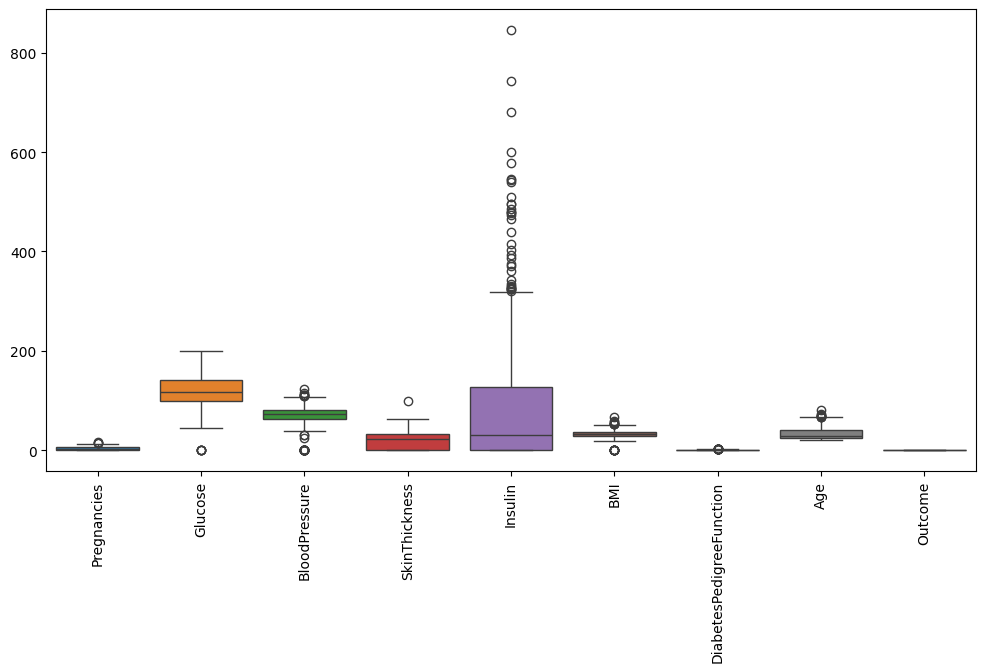

In [16]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

# Remove Outliers using IQR Method

In [19]:
Q1=df.quantile(0.25)

Q3=df.quantile(0.75)

IQR=Q3-Q1


df=df[
~((df < (Q1-1.5*IQR)) |
(df > (Q3+1.5*IQR))).any(axis=1)
]

In [20]:
# Create BMI category:

def bmi_category(x):

    if x < 18.5:
        return "Underweight"

    elif x < 25:
        return "Normal"

    elif x < 30:
        return "Overweight"

    else:
        return "Obese"


df["BMI_Category"] = df["BMI"].apply(bmi_category)

In [22]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1,Obese
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,0,Overweight
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1,Normal
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,Overweight
4,0.0,137.0,40.0,35.0,168.0,43.1,1.200,33.0,1,Obese


In [23]:
# Convert categorical feature:

df=pd.get_dummies(
df,
columns=["BMI_Category"],
drop_first=True
)

In [24]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category_Obese,BMI_Category_Overweight,BMI_Category_Underweight
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1,True,False,False
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,0,False,True,False
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1,False,False,False
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,False,True,False
4,0.0,137.0,40.0,35.0,168.0,43.1,1.200,33.0,1,True,False,False


# Data Visualization

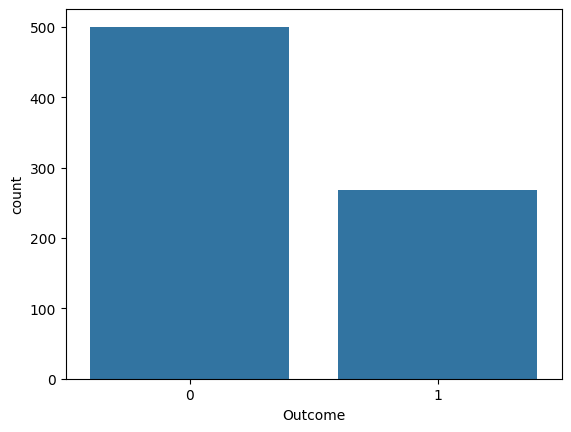

In [25]:
# Diabetes Distribution
sns.countplot(
x="Outcome",
data=df
)

plt.show()

Observation:

Dataset is slightly imbalanced.

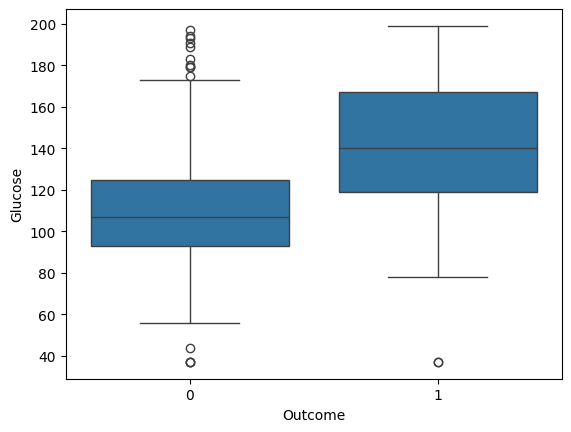

In [26]:
# Glucose vs Diabetes
sns.boxplot(
x="Outcome",
y="Glucose",
data=df
)

plt.show()

Insight:

Patients with diabetes have higher glucose levels.

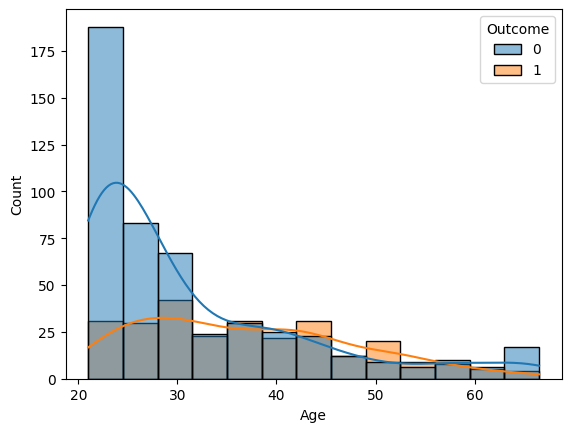

In [27]:
# Age Distribution
sns.histplot(
data=df,
x="Age",
hue="Outcome",
kde=True
)

plt.show()

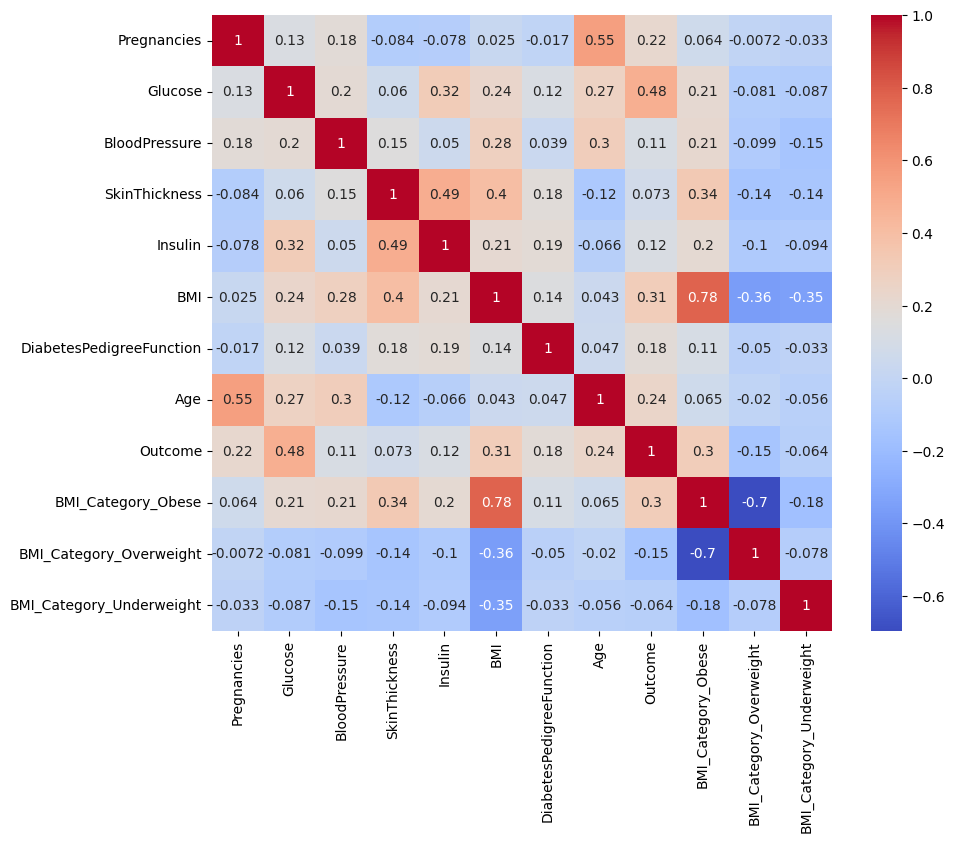

In [28]:
# Correlation Analysis
plt.figure(figsize=(10,8))

sns.heatmap(
df.corr(),
annot=True,
cmap="coolwarm"
)

plt.show()

# Part B – Model Development

# Dataset Splitting

In [29]:
X=df.drop("Outcome",axis=1)

y=df["Outcome"]

In [30]:
X_train,X_test,y_train,y_test=train_test_split(

X,
y,
test_size=0.2,
random_state=42

)

# Feature Scaling

In [31]:
scaler=StandardScaler()


X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

# Model Development

In [32]:
from sklearn.linear_model import LogisticRegression


lr=LogisticRegression()


lr.fit(
X_train,
y_train
)


pred=lr.predict(X_test)

In [33]:
accuracy_score(
y_test,
pred
)

0.7597402597402597

In [43]:
from sklearn.ensemble import RandomForestClassifier


rf=RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)


rf.fit(
    X_train,
    y_train
)


rf_pred=rf.predict(X_test)



rf_accuracy=accuracy_score(
    y_test,
    rf_pred
)


print(
"Random Forest Accuracy:",
rf_accuracy
)

Random Forest Accuracy: 0.7597402597402597


In [44]:
from sklearn.model_selection import GridSearchCV


param_grid={

'n_estimators':[100,200,300],

'max_depth':[3,5,7,10],

'min_samples_split':[2,5,10]

}



grid=GridSearchCV(

RandomForestClassifier(
random_state=42
),

param_grid,

cv=5,

scoring='accuracy'

)



grid.fit(
X_train,
y_train
)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [3, 5, 7, 10],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [45]:
best_model=grid.best_estimator_

In [46]:
final_pred=best_model.predict(X_test)

In [47]:
accuracy_score(
y_test,
final_pred
)

0.7402597402597403

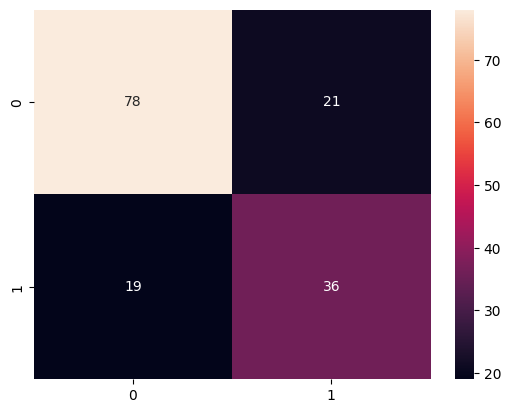

In [48]:
cm=confusion_matrix(
y_test,
final_pred
)


sns.heatmap(
cm,
annot=True
)

plt.show()

In [49]:
print(
classification_report(
y_test,
final_pred
)
)

              precision    recall  f1-score   support

           0       0.80      0.79      0.80        99
           1       0.63      0.65      0.64        55

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154



In [50]:
prob=best_model.predict_proba(X_test)[:,1]


auc=roc_auc_score(
y_test,
prob
)


print(auc)

0.8247933884297521


In [51]:
importance=pd.DataFrame({

"Feature":X.columns,

"Importance":
best_model.feature_importances_

})


importance.sort_values(
by="Importance",
ascending=False
)

,Feature,Importance
1,Glucose,0.254414
7,Age,0.150127
5,BMI,0.141591
6,DiabetesPedigreeFunction,0.114536
2,BloodPressure,0.082874
0,Pregnancies,0.070390
4,Insulin,0.069479
3,SkinThickness,0.068189
8,BMI_Category_Obese,0.036516
9,BMI_Category_Overweight,0.010834


# Part C – Interpretation & Decision Making

1. What business problem was solved?

The healthcare organization needed a system to identify patients who have a high risk of diabetes.

The ML model provides early prediction so doctors can perform preventive interventions.

2. Which variables influenced the outcome most?

Most important factors:

1. Glucose Level

Higher glucose strongly increases diabetes risk.

2. BMI

Higher BMI indicates obesity risk.

3. Age

Risk increases with age.

4. Pregnancy History

Higher pregnancies are associated with increased risk.

3. What insights were discovered?

Insights:

Patients with high glucose have significantly higher diabetes probability.
Obese patients are more likely to develop diabetes.
Age is an important risk factor.
Family/genetic history contributes to prediction.
Early screening can reduce future complications.
4. What risks exist in deployment?
Medical Risks

False negatives:

A diabetic patient predicted as healthy.

Impact:

Delayed treatment.

Data Bias

Dataset contains limited population information.

Model may not generalize to all regions.

Privacy Risk

Patient health data must be protected.

Model Risk

Medical conditions change over time, requiring model updates.

5. Final Recommendation to Management

Recommended solution:

Implement the ML prediction system as a decision-support tool for doctors.

Use it for:

Patient screening
High-risk identification
Preventive healthcare programs

Recommendations:

Monitor patients with high glucose and BMI.
Provide lifestyle improvement programs.
Perform regular health checkups for high-risk groups.
Retrain model periodically with new patient data.
Use model predictions along with doctor expertise, not as a replacement.
Final Conclusion

The Random Forest classification model successfully predicts diabetes risk using patient medical information.

The model helps healthcare organizations move from reactive treatment to preventive healthcare by identifying high-risk patients early.